In [5]:
!pip install openpyxl

In [6]:
import pandas as pd
import numpy as np

In [9]:
file_path="/home/susan/Shyam/Autonomous-AI-Data-Aanalyst/data/Telco_customer_churn.xlsx"
df=pd.read_excel(file_path)


In [10]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [12]:
df.shape

(7043, 33)

In [13]:
numerical_cols=df.select_dtypes(include=np.number).columns.tolist()

categorical_cols=df.select_dtypes(include="object").columns.tolist()

print("Numerical_columns:",numerical_cols)
print("Categorical_columns:",categorical_cols)

Numerical_columns: ['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
Categorical_columns: ['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Label', 'Churn Reason']


In [14]:
df[numerical_cols].describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [15]:
df[categorical_cols].describe().T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [17]:
important_categorical_columns = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Contract",
    "Payment Method",
    "Churn Label"
]

for column in important_categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Gender ---
Gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Senior Citizen ---
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     5416
Yes    1627
Name: count, dtype: int64

--- Contract ---
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

--- Payment Method ---
Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

--- Churn Label ---
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [18]:
churn_counts=df["Churn Label"].value_counts()
churn_counts

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
churn_percentages = df["Churn Label"].value_counts(normalize=True) * 100

churn_percentages

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [20]:
churn_summary = pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_percentages.round(2)
})

churn_summary

,Count,Percentage
Churn Label,,
No,5174,73.46
Yes,1869,26.54


In [21]:
df["Churn Reason"].value_counts()


Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Lack of affordable download/upload speed      44
Limited range of services                     44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

In [22]:
churned_customers = df[df["Churn Label"] == "Yes"]

churned_customers["Churn Reason"].value_counts()

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Lack of affordable download/upload speed      44
Limited range of services                     44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

In [23]:
most_common_churn_reason = (
    churned_customers["Churn Reason"]
    .value_counts()
    .idxmax()
)

most_common_churn_reason

'Attitude of support person'

In [24]:
most_common_churn_reason_count = (
    churned_customers["Churn Reason"]
    .value_counts()
    .max()
)

most_common_churn_reason_count

np.int64(192)

In [25]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"]
)

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [26]:
churn_by_contract = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

churn_by_contract.round(2)

Churn Label,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [27]:
df.groupby("Churn Label")["Monthly Charges"].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

In [28]:
df.groupby("Churn Label")["Tenure Months"].mean()

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

In [29]:
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
).round(3) * 100

Churn Label,No,Yes
Internet Service,,
DSL,81.0,19.0
Fiber optic,58.1,41.9
No,92.6,7.4


In [30]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

Churn Reason    5174
dtype: int64

In [31]:
def generate_dataset_profile(df):
    
    profile = {
        "rows": df.shape[0],
        "columns": df.shape[1],
        "numerical_columns": df.select_dtypes(include=np.number).columns.tolist(),
        "categorical_columns": df.select_dtypes(include="object").columns.tolist(),
        "missing_values": df.isnull().sum().to_dict(),
        "duplicate_rows": int(df.duplicated().sum())
    }
    
    return profile

In [32]:
profile = generate_dataset_profile(df)

profile

{'rows': 7043,
 'columns': 33,
 'numerical_columns': ['Count',
  'Zip Code',
  'Latitude',
  'Longitude',
  'Tenure Months',
  'Monthly Charges',
  'Churn Value',
  'Churn Score',
  'CLTV'],
 'categorical_columns': ['CustomerID',
  'Country',
  'State',
  'City',
  'Lat Long',
  'Gender',
  'Senior Citizen',
  'Partner',
  'Dependents',
  'Phone Service',
  'Multiple Lines',
  'Internet Service',
  'Online Security',
  'Online Backup',
  'Device Protection',
  'Tech Support',
  'Streaming TV',
  'Streaming Movies',
  'Contract',
  'Paperless Billing',
  'Payment Method',
  'Total Charges',
  'Churn Label',
  'Churn Reason'],
 'missing_values': {'CustomerID': 0,
  'Count': 0,
  'Country': 0,
  'State': 0,
  'City': 0,
  'Zip Code': 0,
  'Lat Long': 0,
  'Latitude': 0,
  'Longitude': 0,
  'Gender': 0,
  'Senior Citizen': 0,
  'Partner': 0,
  'Dependents': 0,
  'Tenure Months': 0,
  'Phone Service': 0,
  'Multiple Lines': 0,
  'Internet Service': 0,
  'Online Security': 0,
  'Online Backu

In [33]:
print("Rows:", profile["rows"])
print("Columns:", profile["columns"])

print("\nNumerical columns:")
print(profile["numerical_columns"])

print("\nCategorical columns:")
print(profile["categorical_columns"])

print("\nDuplicate rows:", profile["duplicate_rows"])

Rows: 7043
Columns: 33

Numerical columns:
['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']

Categorical columns:
['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Label', 'Churn Reason']

Duplicate rows: 0


In [34]:
df["CustomerID"].duplicated().sum()

np.int64(0)

In [36]:
df["CustomerID"].nunique()

7043

In [37]:
len(df)

7043

In [38]:
# create something closer to our actual AI Data Analyst
def generate_basic_insights(df):
    
    insights = []
    
    # Dataset size
    insights.append(
        f"The dataset contains {len(df)} customers and {len(df.columns)} columns."
    )
    
    # Churn rate
    churn_rate = (df["Churn Label"] == "Yes").mean() * 100
    
    insights.append(
        f"The overall churn rate is {churn_rate:.2f}%."
    )
    
    # Most common contract
    most_common_contract = df["Contract"].value_counts().idxmax()
    
    insights.append(
        f"The most common contract type is {most_common_contract}."
    )
    
    # Average monthly charges
    average_monthly_charges = df["Monthly Charges"].mean()
    
    insights.append(
        f"The average monthly charge is {average_monthly_charges:.2f}."
    )
    
    # Average tenure
    average_tenure = df["Tenure Months"].mean()
    
    insights.append(
        f"The average customer tenure is {average_tenure:.2f} months."
    )
    
    return insights

In [39]:
insights = generate_basic_insights(df)

for insight in insights:
    print("-", insight)

- The dataset contains 7043 customers and 33 columns.
- The overall churn rate is 26.54%.
- The most common contract type is Month-to-month.
- The average monthly charge is 64.76.
- The average customer tenure is 32.37 months.


#visualization

In [40]:
import matplotlib.pyplot as plt


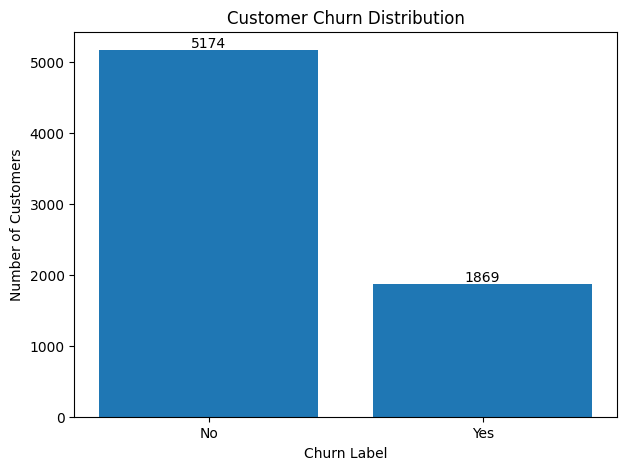

In [42]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")

for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom"
    )

plt.show()

In [43]:
churn_percentage = (
    df["Churn Label"]
    .value_counts(normalize=True)
    * 100
)

churn_percentage

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

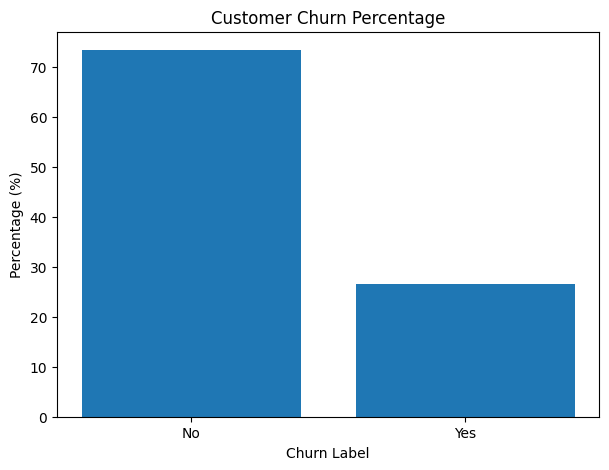

In [44]:
plt.figure(figsize=(7, 5))

plt.bar(
    churn_percentage.index,
    churn_percentage.values
)

plt.xlabel("Churn Label")
plt.ylabel("Percentage (%)")
plt.title("Customer Churn Percentage")

plt.show()

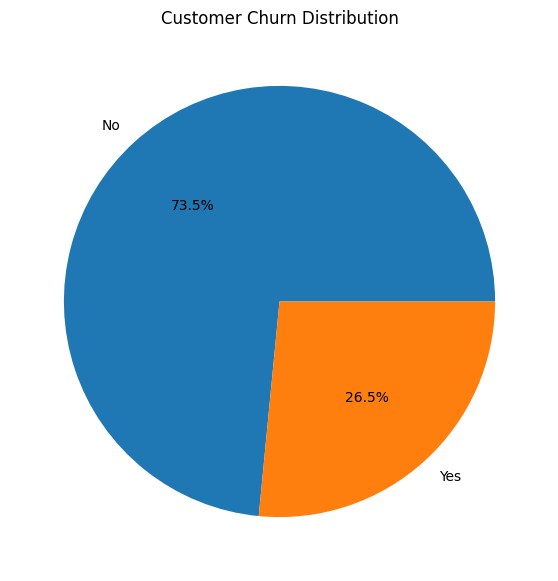

In [45]:
plt.figure(figsize=(7, 7))

plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct="%1.1f%%"
)

plt.title("Customer Churn Distribution")

plt.show()

In [47]:
contract_counts = df["Contract"].value_counts()

contract_counts

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

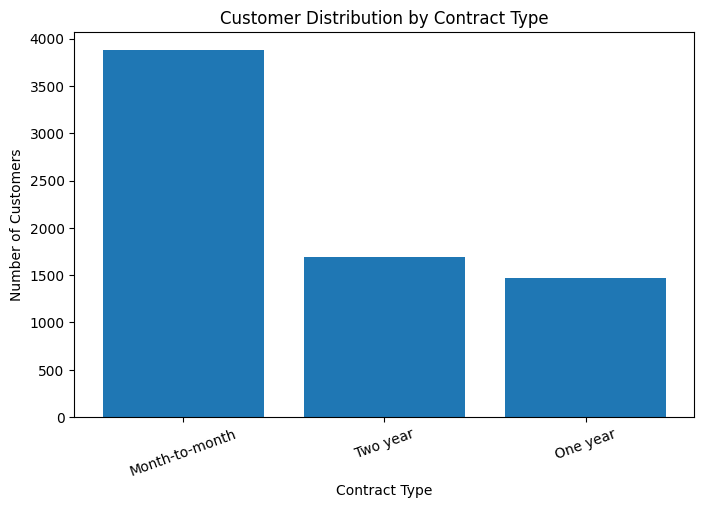

In [48]:
plt.figure(figsize=(8, 5))

plt.bar(
    contract_counts.index,
    contract_counts.values
)

plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Contract Type")

plt.xticks(rotation=20)

plt.show()

In [49]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"]
)

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


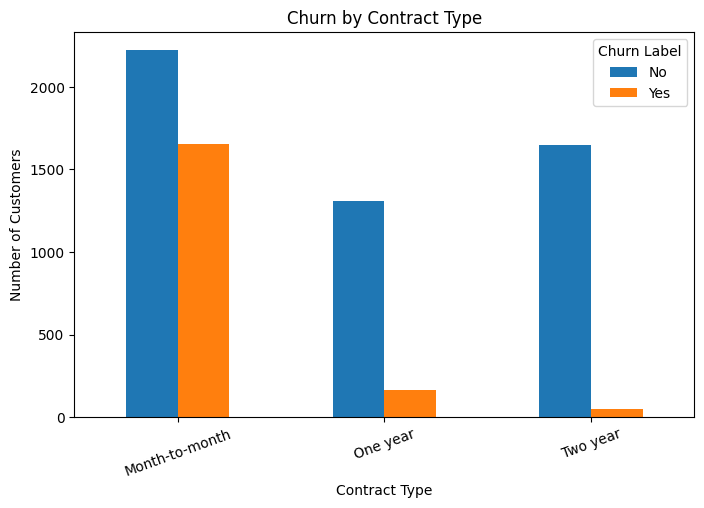

In [50]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Churn by Contract Type")

plt.xticks(rotation=20)

plt.show()

In [51]:
contract_churn_percentage = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

contract_churn_percentage.round(2)

Churn Label,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


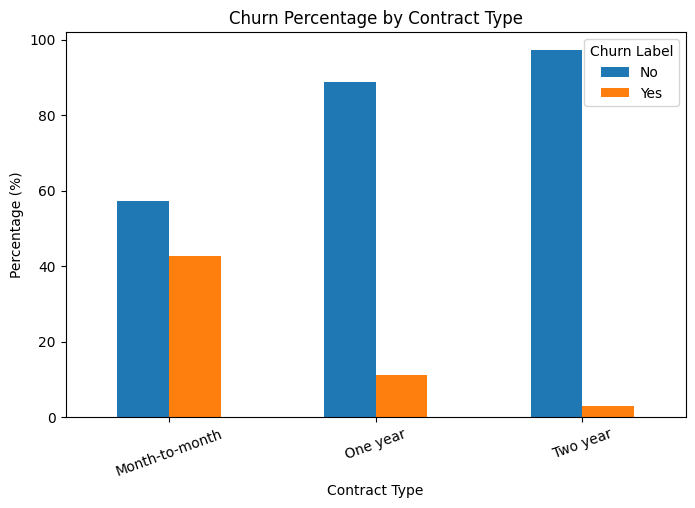

In [52]:
contract_churn_percentage.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.title("Churn Percentage by Contract Type")

plt.xticks(rotation=20)

plt.show()

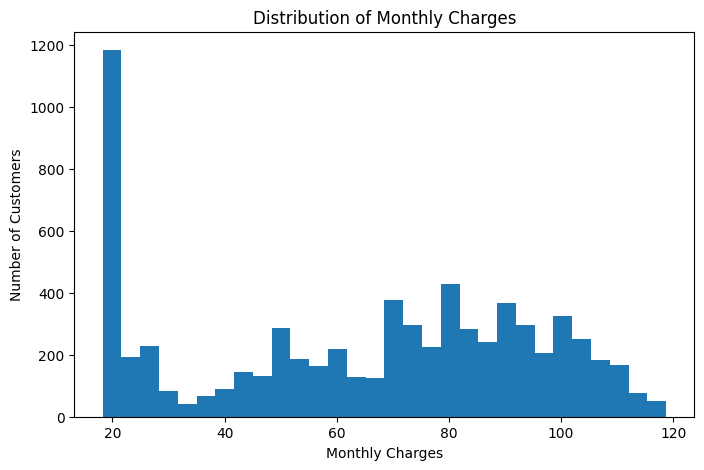

In [53]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Monthly Charges"],
    bins=30
)

plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")

plt.show()

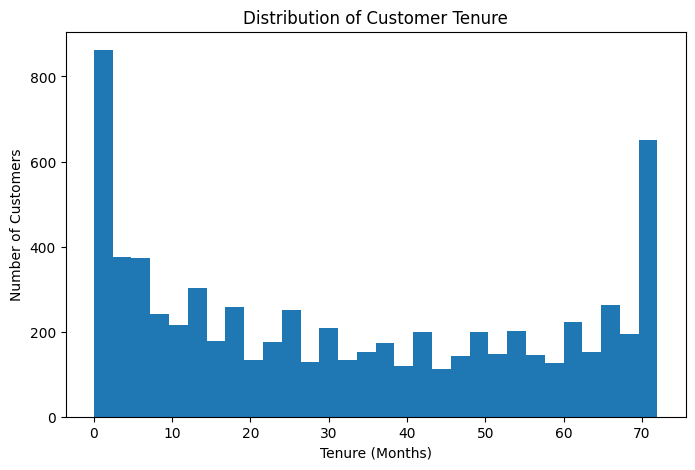

In [55]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Tenure Months"],
    bins=30
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Tenure")

plt.show()

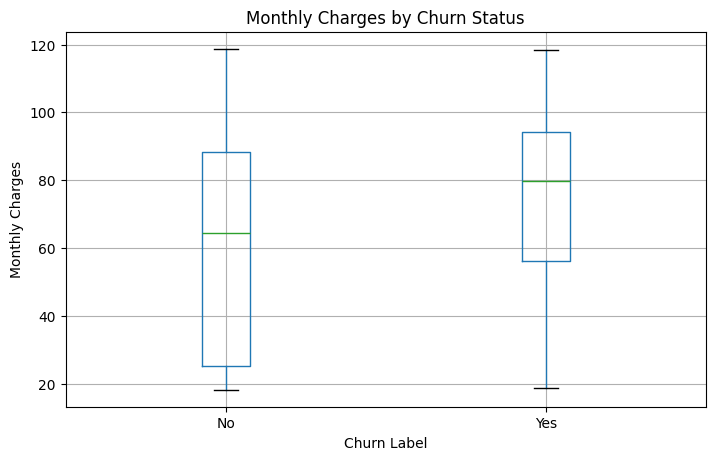

In [56]:
df.boxplot(
    column="Monthly Charges",
    by="Churn Label",
    figsize=(8, 5)
)

plt.xlabel("Churn Label")
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges by Churn Status")

plt.suptitle("")

plt.show()

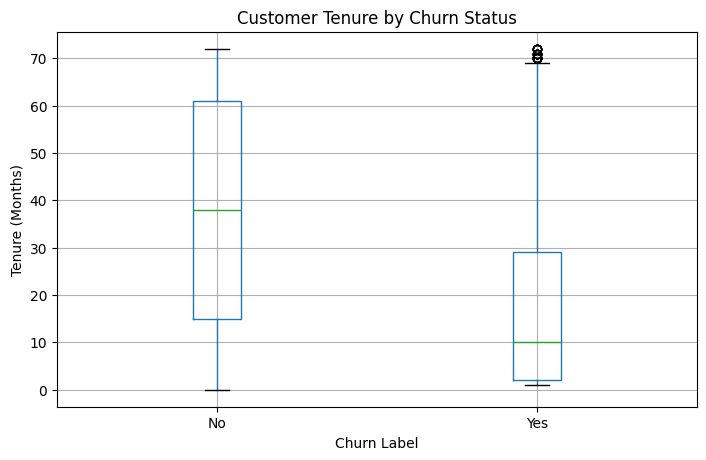

In [57]:
df.boxplot(
    column="Tenure Months",
    by="Churn Label",
    figsize=(8, 5)
)

plt.xlabel("Churn Label")
plt.ylabel("Tenure (Months)")
plt.title("Customer Tenure by Churn Status")

plt.suptitle("")

plt.show()

In [58]:
numerical_df = df.select_dtypes(include=np.number)

correlation = numerical_df.corr()

correlation

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,NaN,1.000000,0.895743,-0.784271,0.001041,-0.004596,0.003346,-0.002769,-0.003562
Latitude,NaN,0.895743,1.000000,-0.876779,-0.001631,-0.019899,-0.003384,-0.007684,0.000886
Longitude,NaN,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.004594,0.004260,0.000485
Tenure Months,NaN,0.001041,-0.001631,-0.001678,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,NaN,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,NaN,0.003346,-0.003384,0.004594,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,NaN,-0.002769,-0.007684,0.004260,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,NaN,-0.003562,0.000886,0.000485,0.396406,0.098693,-0.127463,-0.079782,1.000000


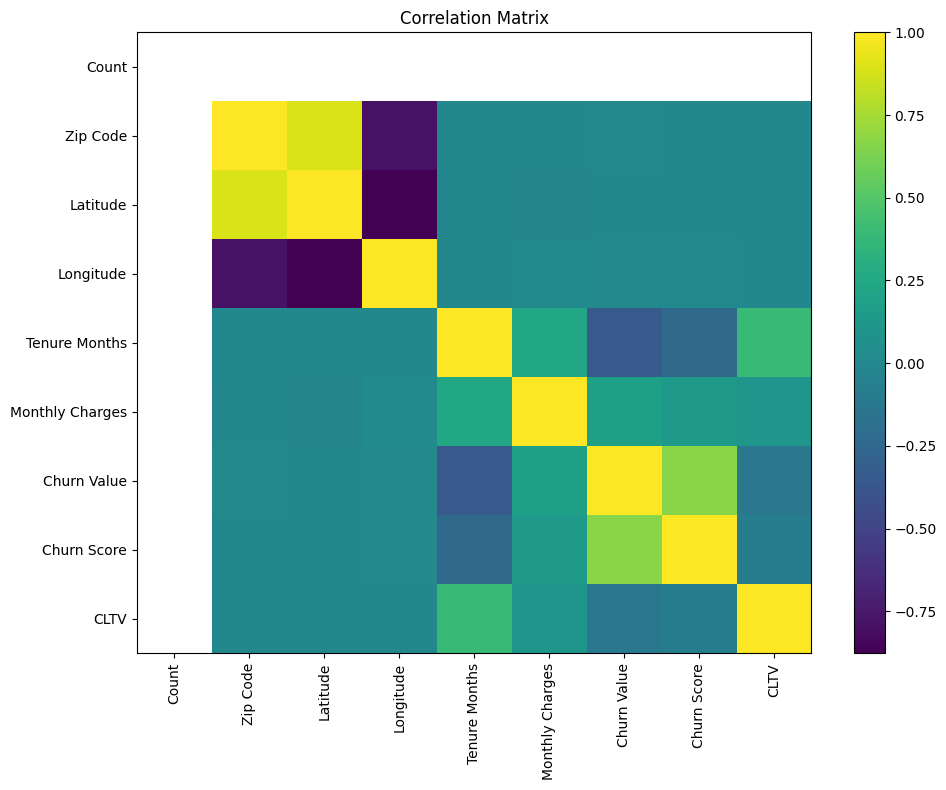

In [59]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [60]:
def plot_categorical_distribution(df, column_name):
    
    counts = df[column_name].value_counts()

    plt.figure(figsize=(8, 5))

    plt.bar(
        counts.index,
        counts.values
    )

    plt.xlabel(column_name)
    plt.ylabel("Count")
    plt.title(f"Distribution of {column_name}")

    plt.xticks(rotation=30)

    plt.show()

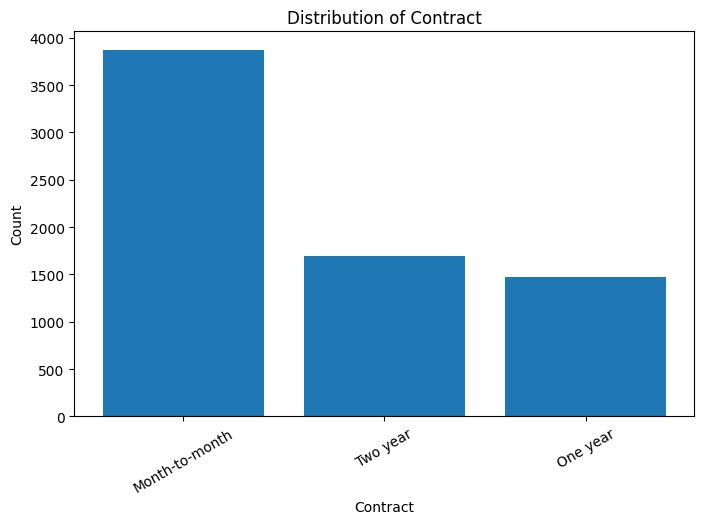

In [61]:
plot_categorical_distribution(df, "Contract")

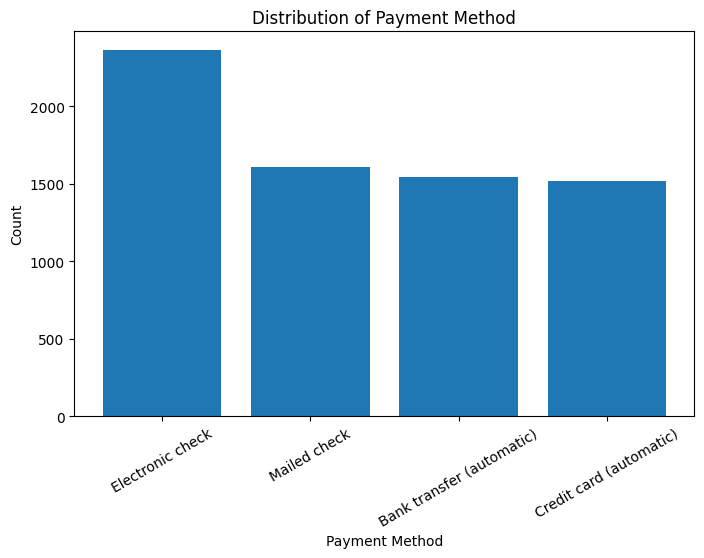

In [62]:
plot_categorical_distribution(df, "Payment Method")

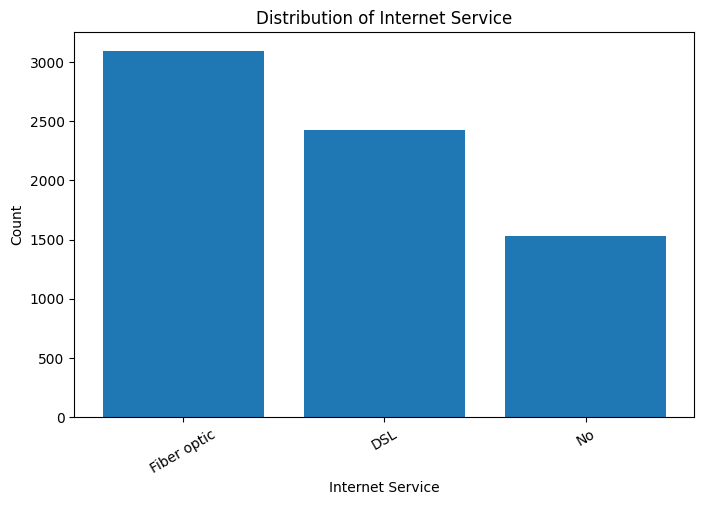

In [64]:
plot_categorical_distribution(df, "Internet Service")

In [65]:
def plot_numerical_distribution(df, column_name):
    
    plt.figure(figsize=(8, 5))

    plt.hist(
        df[column_name].dropna(),
        bins=30
    )

    plt.xlabel(column_name)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column_name}")

    plt.show()

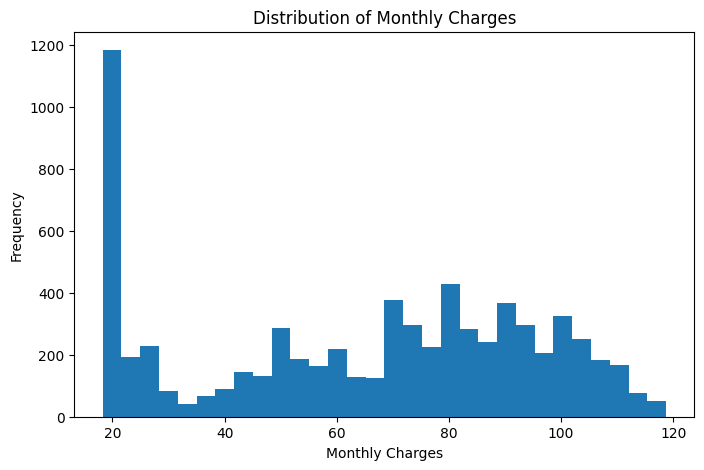

In [66]:
plot_numerical_distribution(df, "Monthly Charges")

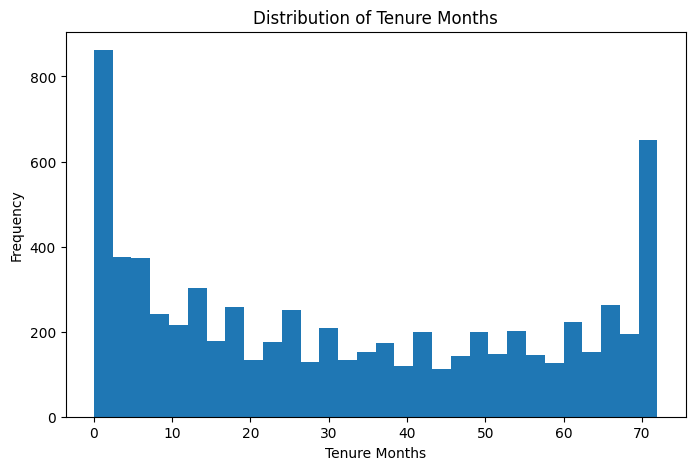

In [67]:
plot_numerical_distribution(df, "Tenure Months")

In [68]:
def choose_visualization(df, column_name):
    
    if column_name not in df.columns:
        return f"Column '{column_name}' does not exist."
    
    if pd.api.types.is_numeric_dtype(df[column_name]):
        return "histogram"
    
    return "bar_chart"

In [69]:
choose_visualization(df, "Monthly Charges")

'histogram'

In [70]:
choose_visualization(df, "Contract")

'bar_chart'

In [71]:
def visualize_column(df, column_name):
    
    visualization_type = choose_visualization(df, column_name)
    
    if visualization_type == "histogram":
        
        plot_numerical_distribution(df, column_name)
        
    elif visualization_type == "bar_chart":
        
        plot_categorical_distribution(df, column_name)
        
    else:
        
        print(visualization_type)

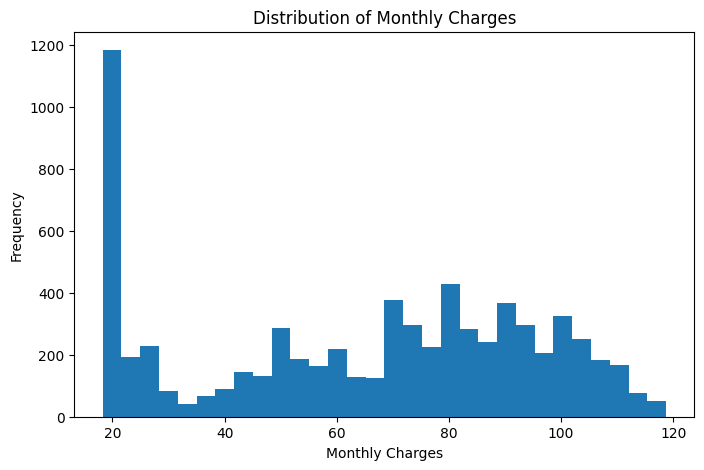

In [72]:
visualize_column(df, "Monthly Charges")

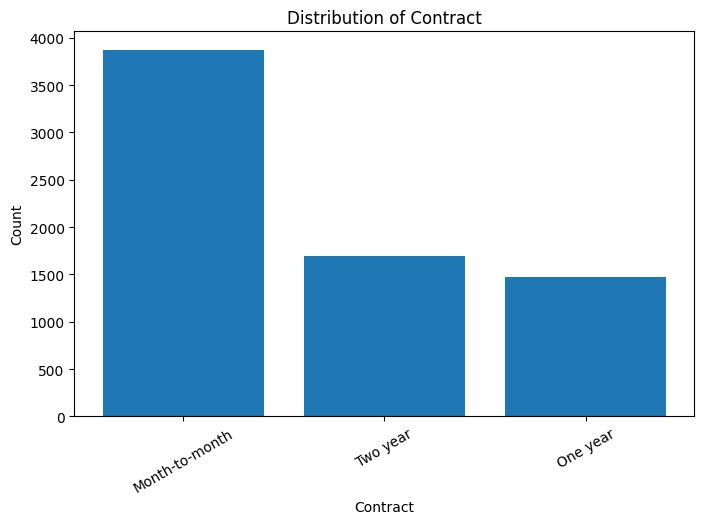

In [73]:
visualize_column(df, "Contract")